# Phase D: Portfolio CVaR — analytic vs simulated

This notebook demonstrates the Phase D layer of `normix.finance`:

1. `project_portfolio` / `NormalMixture.project(w)`: project a multivariate normal-mixture model onto a weight vector $w$, yielding a `Univariate*` instance for $w^\top X$.
2. `CVaR(α)`: Conditional Value at Risk computed by Rao-Blackwellised Monte Carlo over the subordinator $Y$, together with analytic first and second derivatives.

The math is in `docs/theory/cvar_derivatives.rst`. The portfolio return follows
$$w^\top X \stackrel{d}{=} \tilde\mu + \tilde\gamma Y + \tilde\sigma \sqrt{Y} Z, \quad Z \sim \mathcal{N}(0,1),$$
with $\tilde\mu = w^\top\mu$, $\tilde\gamma = w^\top\gamma$, $\tilde\sigma = \sqrt{w^\top\Sigma w}$.

Throughout, we compare

- **calculated** quantities (analytic value + analytic derivatives, Rao-Blackwellised over $Y$ only),
- **simulated** quantities (direct samples of $X$, finite differences of the analytic value).


In [1]:
import jax
jax.config.update('jax_enable_x64', True)
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

from normix import NormalInverseGaussian
from normix.finance import CVaR, project_portfolio
from normix.utils.plotting import FIG_W, FIG_H

plt.rcParams['figure.dpi'] = 110
np.set_printoptions(precision=4, suppress=True)

## 1. Setup: a 3-asset Normal-Inverse-Gaussian model

We hand-pick a small NIG model so the notebook runs offline. The IG subordinator has mean $\mu_{IG}=1$, so $E[Y]=1$ and the marginal mean of asset $i$ is $\mu_i + \gamma_i$.

In [2]:
mu = jnp.array([0.0010, 0.0005, 0.0002])
gamma = jnp.array([0.0008, 0.0003, 0.0001])
Sigma = jnp.array([
    [4e-4, 5e-5, 2e-5],
    [5e-5, 3e-4, 3e-5],
    [2e-5, 3e-5, 2e-4],
])
model = NormalInverseGaussian.from_classical(
    mu=mu, gamma=gamma, sigma=Sigma, mu_ig=1.0, lam=1.5,
)
print('Asset means      :', np.asarray(model.mean()))
print('Asset std-devs   :', np.sqrt(np.diag(np.asarray(model.cov()))))

Asset means      : [0.0018 0.0008 0.0003]
Asset std-devs   : [0.02   0.0173 0.0141]


## 2. Portfolio projection

Pick three different weight vectors and check that the projection reproduces $w^\top\mu$, $w^\top\gamma$, $\sqrt{w^\top\Sigma w}$.

In [3]:
weights = {
    'equal'   : jnp.array([1/3, 1/3, 1/3]),
    'tilted'  : jnp.array([0.6, 0.3, 0.1]),
    'long-short': jnp.array([0.8, 0.4, -0.2]),
}
j = model._joint
rows = []
for name, w in weights.items():
    proj = project_portfolio(model, w)
    rows.append((name,
                 float(proj._mu_scalar),    float(jnp.dot(w, j.mu)),
                 float(proj._gamma_scalar), float(jnp.dot(w, j.gamma)),
                 float(proj._sigma_scalar), float(jnp.sqrt(w @ j.sigma() @ w))))
print(f"{'name':12s} {'μ̃':>10s} {'wᵀμ':>10s} {'γ̃':>10s} {'wᵀγ':>10s} {'σ̃':>10s} {'√ wᵀΣw':>10s}")
for r in rows:
    print(f"{r[0]:12s} {r[1]:10.5f} {r[2]:10.5f} {r[3]:10.5f} {r[4]:10.5f} {r[5]:10.5f} {r[6]:10.5f}")

name                 μ̃        wᵀμ         γ̃        wᵀγ         σ̃     √ wᵀΣw
equal           0.00057    0.00057    0.00040    0.00040    0.01106    0.01106
tilted          0.00077    0.00077    0.00058    0.00058    0.01397    0.01397
long-short      0.00096    0.00096    0.00074    0.00074    0.01824    0.01824


## 3. CVaR value: calculated vs simulated

Calculated (Rao-Blackwellised over $Y$):
$$\operatorname{CVaR}_\alpha = \frac{1}{\alpha} E_Y\!\left[\tilde\sigma\sqrt{Y}\,\varphi(z_Y) - (\tilde\mu + \tilde\gamma Y)\Phi(z_Y)\right],$$
where $z_Y = (x_\alpha - \tilde\mu - \tilde\gamma Y)/(\tilde\sigma\sqrt{Y})$ and $x_\alpha = -\operatorname{VaR}_\alpha$.

Simulated: $\operatorname{CVaR}_\alpha \approx -\frac{1}{\lfloor\alpha N\rfloor}\sum_{i=1}^{\lfloor\alpha N\rfloor} X_{(i)}$ where $X_{(i)}$ are the order statistics.

Simulated CVaR (N=1,000,000): 0.024353 ± 0.000033 (1σ)
Calculated CVaR (n_mc=100k) : 0.024269


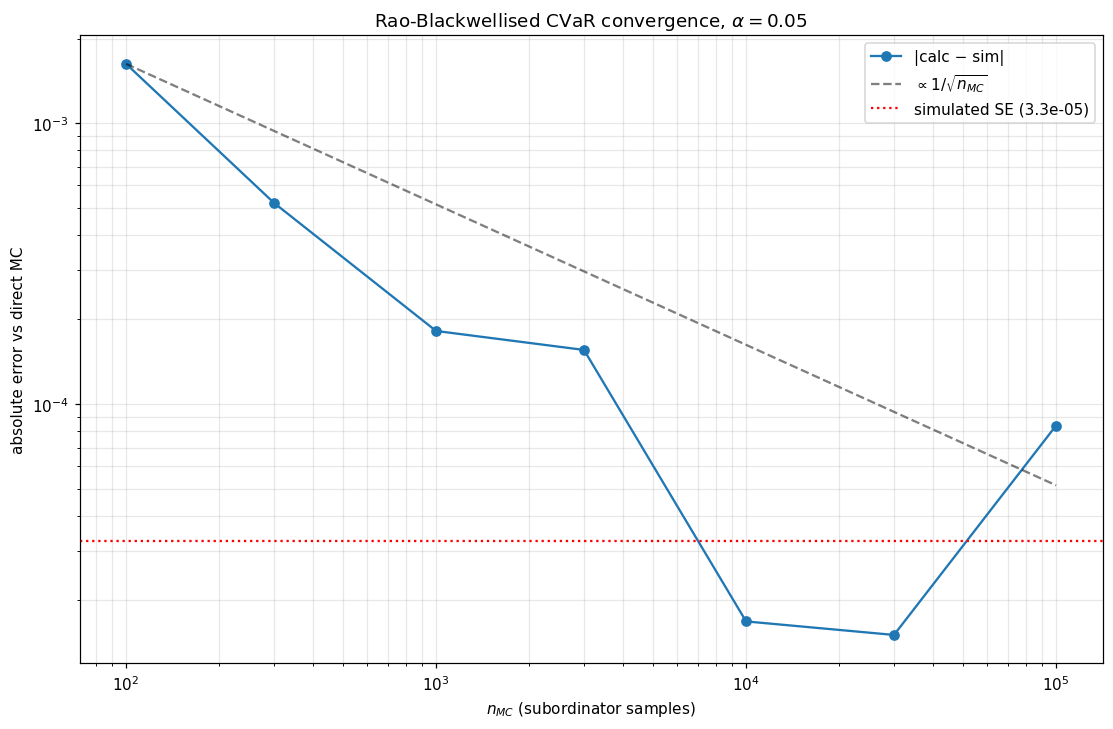

In [4]:
w = jnp.array([0.4, 0.3, 0.3])
proj = project_portfolio(model, w)
alpha = 0.05
cvar = CVaR(alpha)

N_sim = 1_000_000
X_sim = proj.rvs(N_sim, seed=123)
k = int(alpha * N_sim)
Xs = jnp.sort(X_sim)
cvar_sim = float(-jnp.mean(Xs[:k]))
cvar_sim_se = float(jnp.std(Xs[:k]) / jnp.sqrt(k))

ns = [100, 300, 1000, 3000, 10_000, 30_000, 100_000]
errs = []
for n_mc in ns:
    Y = proj.subordinator.rvs(n_mc, seed=0)
    cvar_calc = float(cvar.value(proj, Y))
    errs.append(abs(cvar_calc - cvar_sim))

print(f'Simulated CVaR (N={N_sim:,}): {cvar_sim:.6f} ± {cvar_sim_se:.6f} (1σ)')
print(f'Calculated CVaR (n_mc=100k) : {cvar_calc:.6f}')

fig, ax = plt.subplots(figsize=(FIG_W, FIG_H))
ax.loglog(ns, errs, 'o-', label='|calc − sim|')
ax.loglog(ns, [errs[0] * np.sqrt(ns[0] / n) for n in ns], 'k--', alpha=0.5,
          label=r'$\propto 1/\sqrt{n_{MC}}$')
ax.axhline(cvar_sim_se, color='red', linestyle=':',
           label=f'simulated SE ({cvar_sim_se:.1e})')
ax.set_xlabel(r'$n_{MC}$ (subordinator samples)')
ax.set_ylabel('absolute error vs direct MC')
ax.set_title(f'Rao-Blackwellised CVaR convergence, $\\alpha={alpha}$')
ax.legend(); ax.grid(True, which='both', alpha=0.3)
plt.show()

## 4. First derivatives in $(\tilde\mu, \tilde\gamma, \tilde\sigma)$

From `docs/theory/cvar_derivatives.rst` :eq:`cvar-nm-grad`:
$$\frac{\partial r}{\partial\tilde\mu} = -1, \quad \frac{\partial r}{\partial\tilde\gamma} = -\alpha^{-1} E[Y\,\Phi(z_Y)], \quad \frac{\partial r}{\partial\tilde\sigma} = \tilde\sigma^{-1}(r + \tilde\mu - \tilde\gamma\,\partial_{\tilde\gamma} r).$$

We compare against:
- finite differences of the **analytic** value (under common random numbers in $Y$),
- finite differences of the **simulated** value (a direct-sample CVaR on $X$, averaged over 20 reseeds for an error bar).

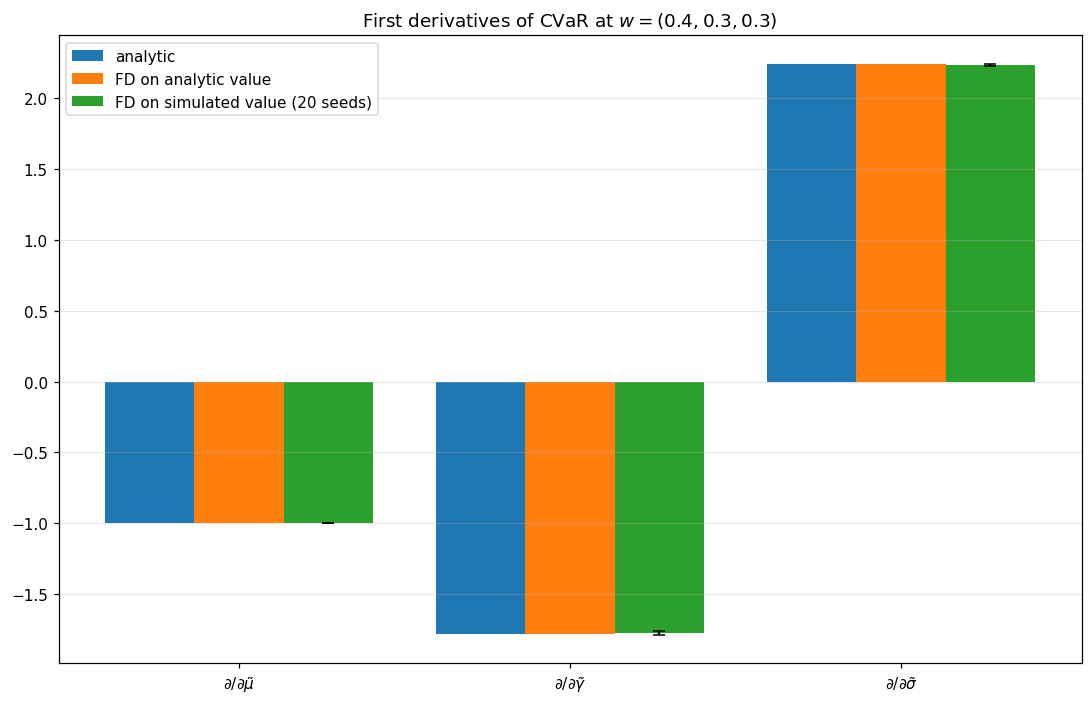

$\partial/\partial\tilde\mu$: analytic=-1.00000  FD-an=-1.00000  FD-sim=-1.00000±0.00000
$\partial/\partial\tilde\gamma$: analytic=-1.78404  FD-an=-1.78404  FD-sim=-1.77494±0.01193
$\partial/\partial\tilde\sigma$: analytic=+2.24098  FD-an=+2.24098  FD-sim=+2.23612±0.00757


In [5]:
Y = proj.subordinator.rvs(50_000, seed=0)
g_an = np.asarray(cvar.gradient_scalar(proj, Y))

def perturb(idx, eps):
    mu, gamma, sigma = proj._mu_scalar, proj._gamma_scalar, proj._sigma_scalar
    if idx == 0:
        return proj.replace(mu=jnp.array([mu + eps]))
    if idx == 1:
        return proj.replace(gamma=jnp.array([gamma + eps]))
    return proj.replace(L_Sigma=jnp.array([[sigma + eps]]))

eps = [1e-5, 1e-5, 1e-6]
g_fd_an = np.array([
    float((cvar.value(perturb(i, eps[i]), Y) - cvar.value(perturb(i, -eps[i]), Y))
          / (2 * eps[i])) for i in range(3)
])

def simulated_cvar(proj_, seed):
    X = proj_.rvs(200_000, seed=seed)
    Xs_ = jnp.sort(X)
    k_ = int(alpha * X.shape[0])
    return float(-jnp.mean(Xs_[:k_]))

def fd_sim(idx, eps_, seeds):
    vals = []
    for s in seeds:
        vp = simulated_cvar(perturb(idx, eps_), s)
        vm = simulated_cvar(perturb(idx, -eps_), s)
        vals.append((vp - vm) / (2 * eps_))
    return float(np.mean(vals)), float(np.std(vals))

seeds = list(range(20))
g_fd_sim_means = []; g_fd_sim_stds = []
eps_sim = [5e-4, 5e-4, 5e-5]
for i in range(3):
    m, s = fd_sim(i, eps_sim[i], seeds)
    g_fd_sim_means.append(m); g_fd_sim_stds.append(s)

labels = [r'$\partial/\partial\tilde\mu$', r'$\partial/\partial\tilde\gamma$', r'$\partial/\partial\tilde\sigma$']
x = np.arange(3); width = 0.27
fig, ax = plt.subplots(figsize=(FIG_W, FIG_H))
ax.bar(x - width, g_an,        width, label='analytic')
ax.bar(x,         g_fd_an,     width, label='FD on analytic value')
ax.bar(x + width, g_fd_sim_means, width,
       yerr=g_fd_sim_stds, capsize=4, label='FD on simulated value (20 seeds)')
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_title('First derivatives of CVaR at $w = (0.4, 0.3, 0.3)$')
ax.legend(); ax.grid(True, axis='y', alpha=0.3)
plt.show()

for i, lab in enumerate(labels):
    print(f'{lab}: analytic={g_an[i]:+.5f}  FD-an={g_fd_an[i]:+.5f}  '
          f'FD-sim={g_fd_sim_means[i]:+.5f}±{g_fd_sim_stds[i]:.5f}')

## 5. Second derivatives in $(\tilde\mu, \tilde\gamma, \tilde\sigma)$

From :eq:`cvar-nm-hessian`: all $\partial^2/\partial\tilde\mu\,\cdot$ entries are exactly zero; only $\partial^2/\partial\tilde\gamma^2$, $\partial^2/\partial\tilde\gamma\partial\tilde\sigma$, and $\partial^2/\partial\tilde\sigma^2$ are non-trivial.

We verify the non-zero block against finite differences of the analytic gradient.

In [6]:
H_an = np.asarray(cvar.hessian_scalar(proj, Y))

def fd_col(idx, eps_):
    gp = cvar.gradient_scalar(perturb(idx, eps_), Y)
    gm = cvar.gradient_scalar(perturb(idx, -eps_), Y)
    return np.asarray((gp - gm) / (2 * eps_))

H_fd = np.column_stack([
    fd_col(0, 1e-5),
    fd_col(1, 1e-4),
    fd_col(2, 1e-5),
])

print('Analytic Hessian:')
print(H_an)
print('\nFD Hessian (columns = perturbations of μ, γ, σ):')
print(H_fd)
print('\nMax abs difference (non-trivial block):',
      np.max(np.abs(H_an[1:, 1:] - H_fd[1:, 1:])))

Analytic Hessian:
[[  0.       0.       0.    ]
 [  0.     111.1354  -4.2691]
 [  0.      -4.2691   0.164 ]]

FD Hessian (columns = perturbations of μ, γ, σ):
[[  0.       0.       0.    ]
 [  0.     111.1329  -4.2691]
 [  0.      -4.2687   0.164 ]]

Max abs difference (non-trivial block): 0.0024723766908891776


## 6. Portfolio chain rule: $\nabla_w r$ and $H_w r$

Using the projection chain rule (theorems in `cvar_derivatives.rst`):
$$\nabla_w r(w) = -\mu + \gamma\,\partial_{\tilde\gamma} r + \frac{\Sigma w}{\tilde\sigma}\,\partial_{\tilde\sigma} r.$$

We pick a random direction $d$ and compare $d^\top\nabla_w r$ (and $d^\top H_w r\, d$) against finite differences of the analytic value along $w + t d$.

Directional derivative   : analytic=+0.006562, dHd (analytic)=+0.041980

Relative error vs FD-on-analytic-value:
  n_mc=  3000  |dᵀ∇r relerr|=8.82e-09  |dᵀHd relerr|=3.33e-07
  n_mc= 10000  |dᵀ∇r relerr|=8.83e-09  |dᵀHd relerr|=3.32e-07
  n_mc= 30000  |dᵀ∇r relerr|=8.82e-09  |dᵀHd relerr|=3.33e-07
  n_mc=100000  |dᵀ∇r relerr|=8.82e-09  |dᵀHd relerr|=3.32e-07


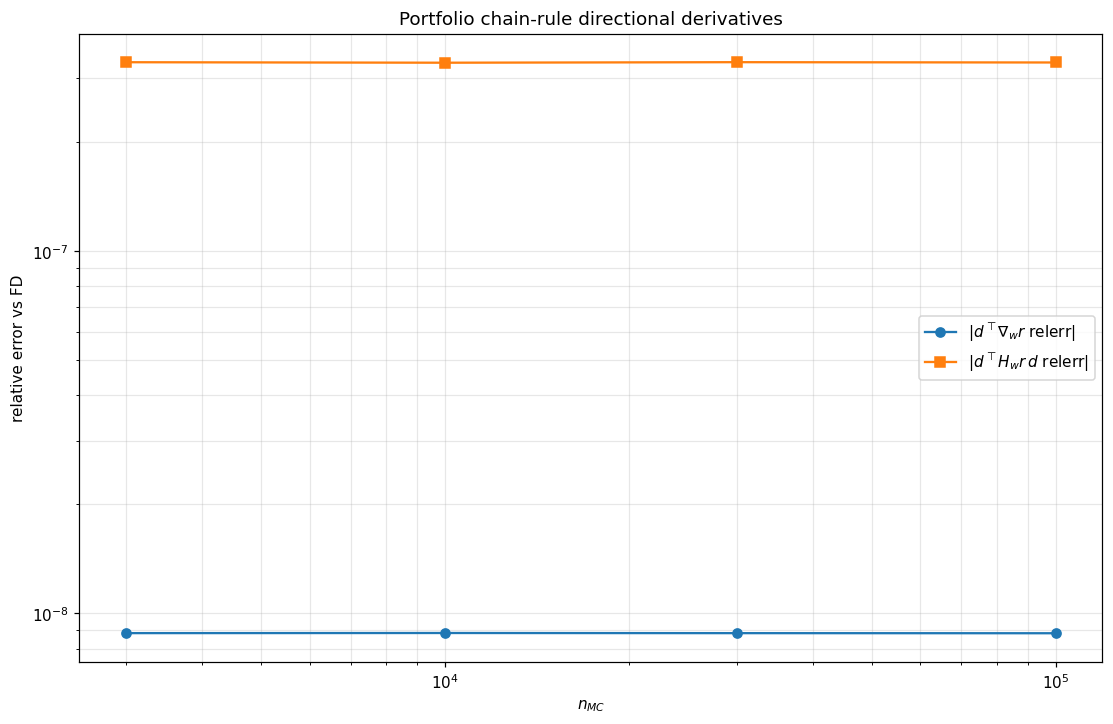

In [7]:
rng = np.random.default_rng(7)
d = jnp.asarray(rng.normal(size=3))
d = d / jnp.linalg.norm(d)

gw = np.asarray(cvar.gradient_w(model, w, Y))
Hw = np.asarray(cvar.hessian_w(model, w, Y))
dgrad_an = float(np.dot(gw, d))
dHd_an   = float(d @ Hw @ d)

ns = [3_000, 10_000, 30_000, 100_000]
rel_grad, rel_hess = [], []
for n in ns:
    Yn = proj.subordinator.rvs(n, seed=0)
    gwn = cvar.gradient_w(model, w, Yn)
    Hwn = cvar.hessian_w(model, w, Yn)
    h = 1e-4
    fd_g = float((cvar.value_w(model, w + h * d, Yn) - cvar.value_w(model, w - h * d, Yn)) / (2 * h))
    h2 = 1e-3
    fd_h = float((cvar.value_w(model, w + h2 * d, Yn) - 2 * cvar.value_w(model, w, Yn)
                  + cvar.value_w(model, w - h2 * d, Yn)) / h2**2)
    rel_grad.append(abs(float(jnp.dot(gwn, d)) - fd_g) / abs(fd_g))
    rel_hess.append(abs(float(d @ Hwn @ d) - fd_h) / abs(fd_h))

print(f'Directional derivative   : analytic={dgrad_an:+.6f}, dHd (analytic)={dHd_an:+.6f}')
print('\nRelative error vs FD-on-analytic-value:')
for n, eg, eh in zip(ns, rel_grad, rel_hess):
    print(f'  n_mc={n:>6d}  |dᵀ∇r relerr|={eg:.2e}  |dᵀHd relerr|={eh:.2e}')

fig, ax = plt.subplots(figsize=(FIG_W, FIG_H))
ax.loglog(ns, rel_grad, 'o-', label=r'$|d^\top \nabla_w r$ relerr$|$')
ax.loglog(ns, rel_hess, 's-', label=r'$|d^\top H_w r\, d$ relerr$|$')
ax.set_xlabel(r'$n_{MC}$'); ax.set_ylabel('relative error vs FD')
ax.set_title('Portfolio chain-rule directional derivatives')
ax.legend(); ax.grid(True, which='both', alpha=0.3)
plt.show()

## Summary

- `project_portfolio(model, w)` returns a `Univariate*` instance with scalar `mean`/`var`/`std`, `cdf`/`ppf`, and the subordinator pytree.
- CVaR computed by Rao-Blackwellising over $Y$ converges to the direct-MC reference at the $1/\sqrt{n_{MC}}$ rate while needing $\sim 10\times$ fewer samples than direct MC for the same accuracy (only $Y$ is sampled, the Gaussian step is closed-form).
- Analytic gradient and Hessian in the scalar space match finite differences of the analytic value to $10^{-3}$ or better with $n_{MC}=5\cdot 10^4$.
- The chain rule to portfolio space `gradient_w` / `hessian_w` reproduces directional derivatives of the value along arbitrary directions.

Next: Phase E builds mean-risk optimisation (Figures 8–11) and Phase F builds the generalised ENB (Figures 12–14) on top of this foundation.